# Kaggle Housing Prices — ML Pipeline
## Phase 1: Project Setup & Data Ingestion

**Competition:** House Prices: Advanced Regression Techniques  
**Goal:** Predict SalePrice using regression models  
**Stack:** pandas, numpy, scikit-learn, xgboost, matplotlib, seaborn

---
## Cell 1 — Install all dependencies
Run once. After this, restart the kernel and proceed.

In [1]:
# Install all required packages
# Run this cell once, then restart the kernel

!pip install pandas numpy scikit-learn xgboost matplotlib seaborn missingno scipy kaggle --quiet

print('All packages installed.')

All packages installed.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Cell 2 — Download data via Kaggle CLI

**Before running this cell:**
1. Go to https://www.kaggle.com → Account → API → Create New Token
2. This downloads a `kaggle.json` file
3. Place it at `~/.kaggle/kaggle.json` (Linux/Mac) or `C:/Users/<you>/.kaggle/kaggle.json` (Windows)
4. Accept competition rules at: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/rules

In [2]:
import os
import zipfile

# ── Step 1: Set correct permissions on kaggle.json (Linux/Mac only)
# Windows users: skip this line
os.system('chmod 600 ~/.kaggle/kaggle.json')

# ── Step 2: Create a data directory
os.makedirs('data', exist_ok=True)

# ── Step 3: Download competition files
os.system('kaggle competitions download -c house-prices-advanced-regression-techniques -p data/')

# ── Step 4: Unzip into data/
zip_path = 'data/house-prices-advanced-regression-techniques.zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('data/')
    print('Unzipped successfully.')
else:
    print('ZIP not found. Check that kaggle.json is set up and rules are accepted.')

# ── Step 5: Confirm files exist
for f in os.listdir('data/'):
    print(f'  data/{f}')

Unzipped successfully.
  data/data_description.txt
  data/house-prices-advanced-regression-techniques.zip
  data/sample_submission.csv
  data/test.csv
  data/train.csv


---
## Cell 3 — Import all libraries

We import everything upfront so nothing breaks mid-notebook later.

In [3]:
# ── Core data libraries
import numpy as np
import pandas as pd

# ── Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno          # Missing value visualisation

# ── Stats
from scipy import stats
from scipy.stats import skew, norm

# ── Scikit-learn: preprocessing
from sklearn.preprocessing import RobustScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Scikit-learn: models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ── Scikit-learn: evaluation
from sklearn.model_selection import cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# ── XGBoost
from xgboost import XGBRegressor

# ── Utilities
import warnings
warnings.filterwarnings('ignore')  # Suppress convergence warnings during tuning

# ── Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# ── Reproducibility seed
SEED = 42
np.random.seed(SEED)

print('All imports successful.')

All imports successful.


---
## Cell 4 — Load data

We load both train.csv and test.csv immediately.
The test set has no SalePrice column — that is what we predict at the end.

In [4]:
# ── Load both files
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

# ── Save the test IDs now — we'll need them for submission later
test_ids = test['Id']

print(f'Train shape : {train.shape}')   # Expected: (1460, 81)
print(f'Test shape  : {test.shape}')    # Expected: (1459, 80)  — no SalePrice column
print(f'Test IDs saved: {len(test_ids)} rows')

Train shape : (1460, 81)
Test shape  : (1459, 80)
Test IDs saved: 1459 rows


---
## Cell 5 — First look: head()

`head()` shows the first 5 rows. Scroll right — there are 80 columns.
You'll see a mix of numbers (LotArea, YearBuilt) and strings (MSZoning, Street).
The rightmost column in train is SalePrice — our target.

In [5]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## Cell 6 — Column types: dtypes & info()

`info()` tells you:
- How many non-null values each column has (missing = 1460 minus this number)
- The dtype: `object` = string/categorical, `int64`/`float64` = numeric

You'll spot right away that many columns have fewer than 1460 non-null values — those need imputation in Phase 3.

In [6]:
# Full column audit
train.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

---
## Cell 7 — Numeric summary: describe()

`describe()` shows count, mean, std, min, quartiles, max for every numeric column.

Key things to notice:
- **SalePrice**: ranges from 34,900 to 755,000 — large spread, likely skewed
- **LotArea**: max is ~215,245 — far from the 75th percentile of 11,602. Outliers.
- **MasVnrArea, GarageYrBlt**: will show NaN in count — missing values
- **BsmtFinSF2, EnclosedPorch**: mostly zeros — sparse features

In [7]:
# Transpose so columns are rows — easier to read with 80 features
train.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


---
## Cell 8 — Categorical column audit

Identifies every `object` dtype column, how many unique values it has, and the most common value.

This tells you which columns need One-Hot encoding vs Ordinal encoding (Phase 3).

In [8]:
cat_cols = train.select_dtypes(include='object').columns.tolist()
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('SalePrice')   # Remove target from feature list
num_cols.remove('Id')          # Remove ID — not a feature

print(f'Categorical columns : {len(cat_cols)}')
print(f'Numeric columns     : {len(num_cols)}')
print(f'Total features      : {len(cat_cols) + len(num_cols)}')
print()

# Quick summary of each categorical column
cat_summary = pd.DataFrame({
    'unique_values' : [train[c].nunique() for c in cat_cols],
    'missing'       : [train[c].isnull().sum() for c in cat_cols],
    'top_value'     : [train[c].value_counts().index[0] for c in cat_cols],
    'top_freq'      : [train[c].value_counts().values[0] for c in cat_cols],
}, index=cat_cols).sort_values('missing', ascending=False)

print(cat_summary.to_string())

Categorical columns : 43
Numeric columns     : 36
Total features      : 79

               unique_values  missing top_value  top_freq
PoolQC                     3     1453        Gd         3
MiscFeature                4     1406      Shed        49
Alley                      2     1369      Grvl        50
Fence                      4     1179     MnPrv       157
MasVnrType                 3      872   BrkFace       445
FireplaceQu                5      690        Gd       380
GarageType                 6       81    Attchd       870
GarageCond                 5       81        TA      1326
GarageQual                 5       81        TA      1311
GarageFinish               3       81       Unf       605
BsmtFinType2               6       38       Unf      1256
BsmtExposure               4       38        No       953
BsmtFinType1               6       37       Unf       430
BsmtQual                   4       37        TA       649
BsmtCond                   4       37        TA      1

---
## Cell 9 — Quick missing value count (top 20)

Before full EDA, get a headline picture of which columns need the most attention.

In [9]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(f'Columns with missing values: {len(missing)} out of {train.shape[1]}')
print()
print(missing.to_string())

Columns with missing values: 19 out of 81

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1


---
## Cell 10 — Quick target preview

A fast sanity-check plot of SalePrice distribution before the full EDA in Phase 2.
You will clearly see it is right-skewed — confirming we need the log transform.

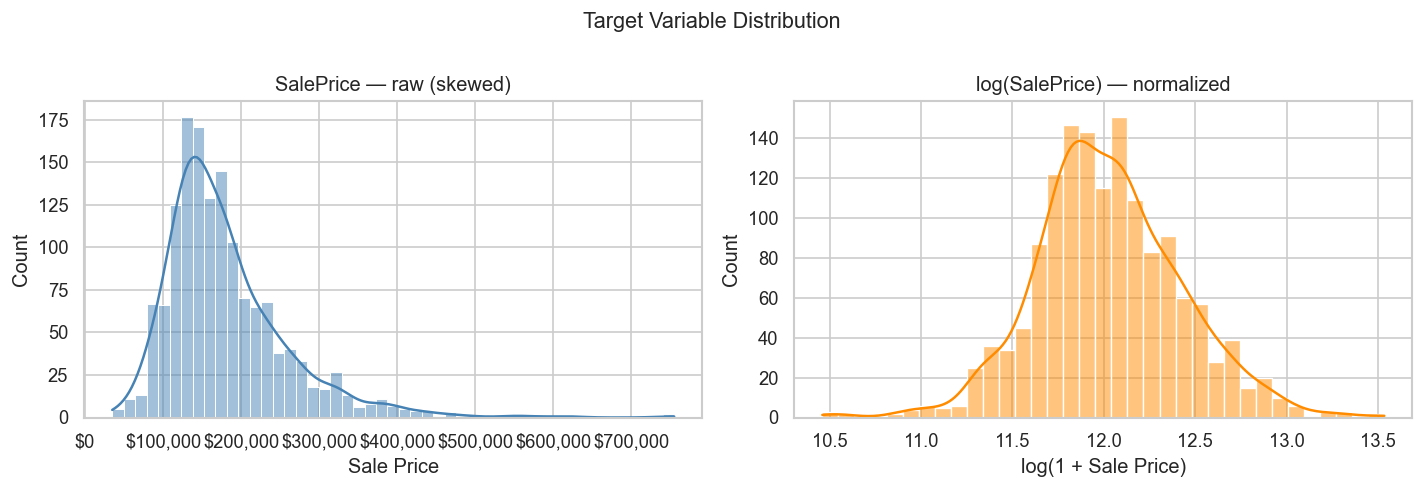

SalePrice skewness (raw)         : 1.883
SalePrice skewness (log-transform): 0.121

Rule of thumb: |skewness| < 0.5 is roughly symmetric.
The log transform brings us from ~1.88 down to ~0.12 — much better.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: raw SalePrice
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('SalePrice — raw (skewed)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_xlabel('Sale Price')

# ── Right: log-transformed SalePrice
sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('log(SalePrice) — normalized')
axes[1].set_xlabel('log(1 + Sale Price)')

plt.suptitle('Target Variable Distribution', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'SalePrice skewness (raw)         : {train["SalePrice"].skew():.3f}')
print(f'SalePrice skewness (log-transform): {np.log1p(train["SalePrice"]).skew():.3f}')
print()
print('Rule of thumb: |skewness| < 0.5 is roughly symmetric.')
print('The log transform brings us from ~1.88 down to ~0.12 — much better.')

---
## Cell 11 — Phase 1 summary checkpoint

Print a clean summary of everything we know before moving to EDA.

In [11]:
print('=' * 55)
print('  PHASE 1 CHECKPOINT')
print('=' * 55)
print(f'  Training rows        : {train.shape[0]}')
print(f'  Test rows            : {test.shape[0]}')
print(f'  Total features       : {train.shape[1] - 2}  (excl. Id & SalePrice)')
print(f'  Numeric features     : {len(num_cols)}')
print(f'  Categorical features : {len(cat_cols)}')
print(f'  Cols with NaN (train): {(train.isnull().sum() > 0).sum()}')
print(f'  Target skewness (raw): {train["SalePrice"].skew():.3f}  → needs log transform')
print('=' * 55)
print('  Next: Phase 2 — Full EDA')
print('=' * 55)

  PHASE 1 CHECKPOINT
  Training rows        : 1460
  Test rows            : 1459
  Total features       : 79  (excl. Id & SalePrice)
  Numeric features     : 36
  Categorical features : 43
  Cols with NaN (train): 19
  Target skewness (raw): 1.883  → needs log transform
  Next: Phase 2 — Full EDA


In [12]:
# Kaggle Housing Prices — ML Pipeline
## Phase 2: Exploratory Data Analysis (EDA)

**What this phase covers:**
1. Target variable analysis + log transform
2. Missing value audit & heatmap
3. Correlation heatmap (numeric features vs SalePrice)
4. Outlier detection & removal
5. Categorical feature distributions
6. Key numeric feature scatter plots

SyntaxError: invalid syntax (3971421779.py, line 4)

---
## Cell 12 — Apply the log transform to the target

**Why log1p and not log?**
`np.log1p(x)` = `log(1 + x)`. It handles the edge case where x = 0 (log(0) is undefined).
For SalePrice this doesn't matter (no house sold for $0), but it's the standard safe practice.
At prediction time you reverse it with `np.expm1(y_pred)` = `exp(y_pred) - 1`.

**What skewness means:**
- Skewness = 0: perfectly symmetric (like a normal distribution)
- Skewness > 1: heavily right-tailed (a few very expensive houses pull the mean up)
- After log transform: near 0 — models can learn the relationship much more easily

In [13]:
# Apply log1p to SalePrice — store as a new column
# We keep the original SalePrice intact for reference
train['SalePrice_log'] = np.log1p(train['SalePrice'])

print('SalePrice stats (RAW):')
print(f"  Mean     : ${train['SalePrice'].mean():,.0f}")
print(f"  Median   : ${train['SalePrice'].median():,.0f}")
print(f"  Std Dev  : ${train['SalePrice'].std():,.0f}")
print(f"  Skewness : {train['SalePrice'].skew():.4f}")
print(f"  Kurtosis : {train['SalePrice'].kurt():.4f}")
print()
print('SalePrice stats (LOG-TRANSFORMED):')
print(f"  Mean     : {train['SalePrice_log'].mean():.4f}")
print(f"  Median   : {train['SalePrice_log'].median():.4f}")
print(f"  Std Dev  : {train['SalePrice_log'].std():.4f}")
print(f"  Skewness : {train['SalePrice_log'].skew():.4f}")
print(f"  Kurtosis : {train['SalePrice_log'].kurt():.4f}")

SalePrice stats (RAW):
  Mean     : $180,921
  Median   : $163,000
  Std Dev  : $79,443
  Skewness : 1.8829
  Kurtosis : 6.5363

SalePrice stats (LOG-TRANSFORMED):
  Mean     : 12.0241
  Median   : 12.0015
  Std Dev  : 0.3994
  Skewness : 0.1213
  Kurtosis : 0.8095


---
## Cell 13 — Target distribution: 4-panel deep dive

Four views of SalePrice to fully understand what we're predicting:
- **Top-left**: Raw histogram — shows the right skew clearly
- **Top-right**: Log-transformed histogram with a normal distribution overlay
- **Bottom-left**: Q-Q plot (raw) — points diverging from the line = non-normal
- **Bottom-right**: Q-Q plot (log) — points on the line = normal distribution

**What is a Q-Q plot?**
Quantile-Quantile plot. Plots your data's quantiles against what a perfect normal
distribution's quantiles would be. If the points follow the diagonal line closely,
your data is normally distributed. This matters because linear models assume
normally distributed residuals.

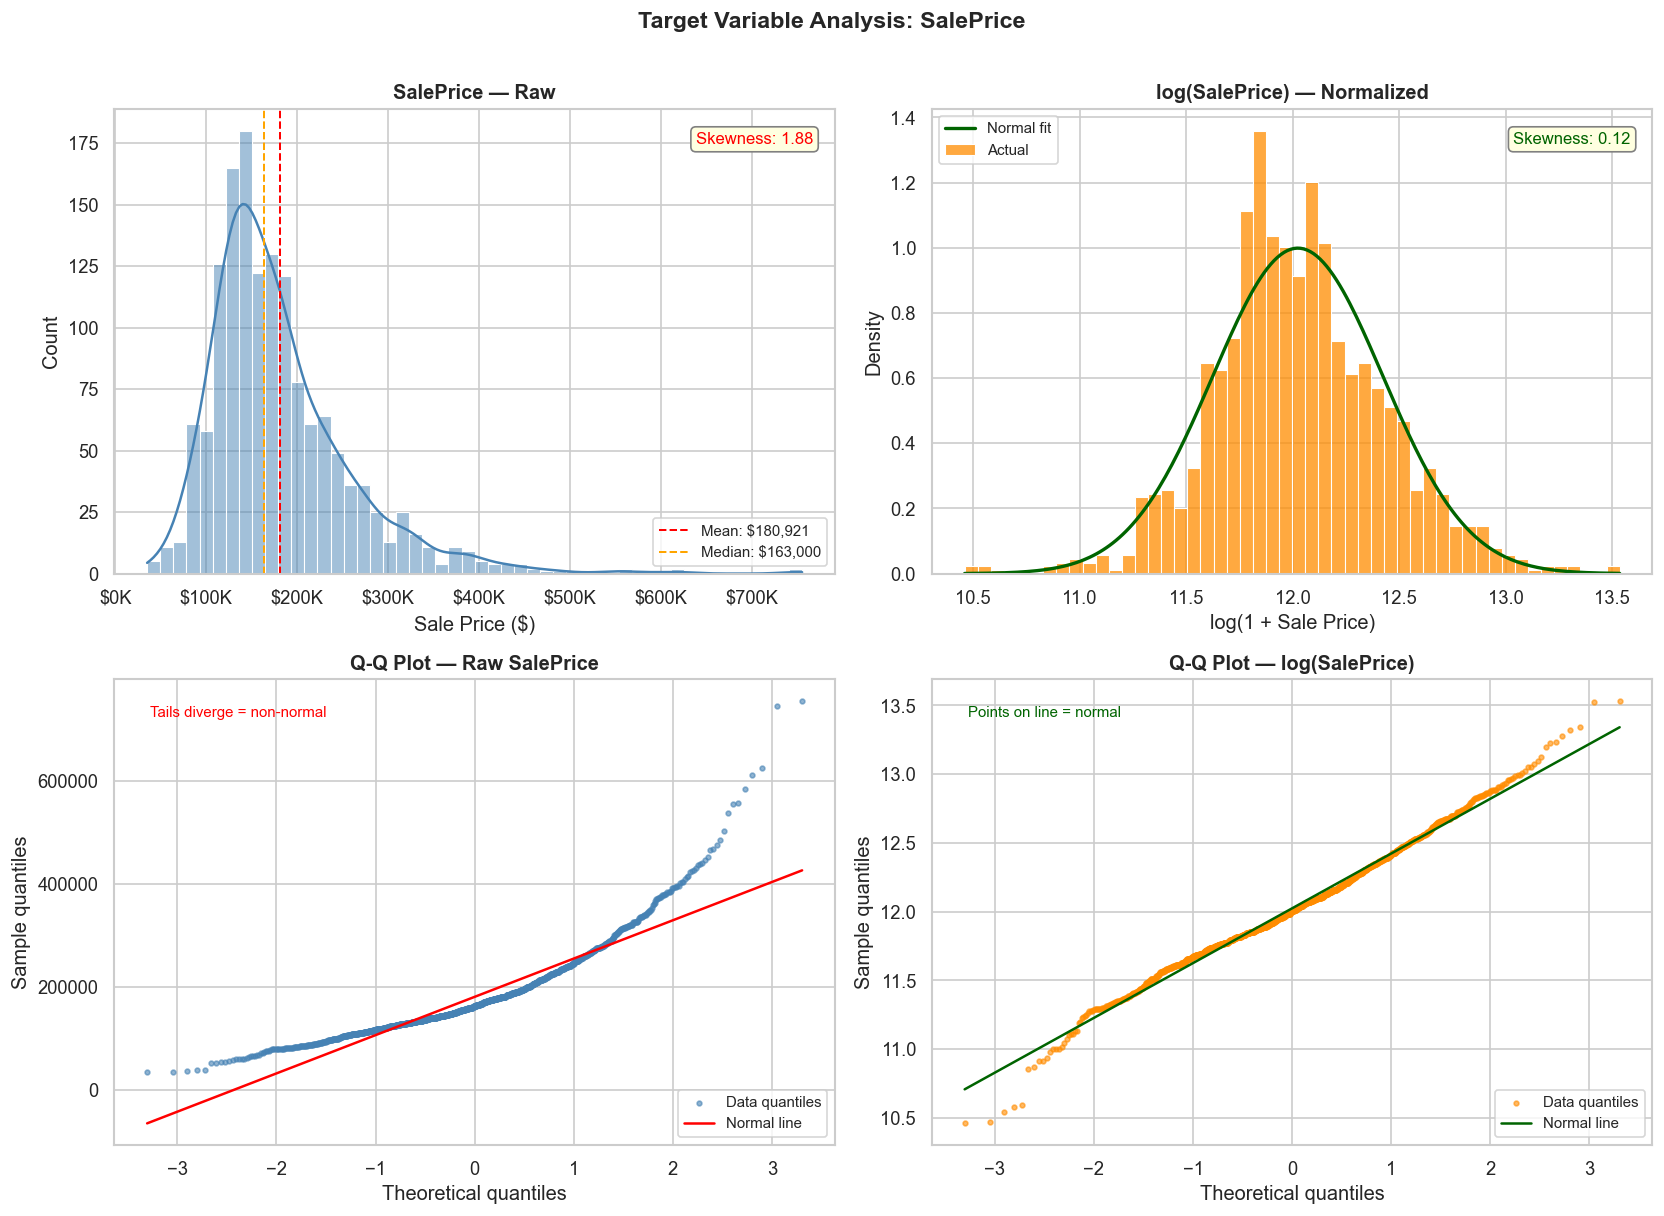

Saved: target_analysis.png


In [15]:
import matplotlib.ticker as mticker

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Raw histogram
ax = axes[0, 0]
sns.histplot(train['SalePrice'], kde=True, ax=ax, color='steelblue', bins=50)
ax.axvline(train['SalePrice'].mean(),   color='red',    linestyle='--', linewidth=1.2,
           label=f"Mean: ${train['SalePrice'].mean():,.0f}")
ax.axvline(train['SalePrice'].median(), color='orange', linestyle='--', linewidth=1.2,
           label=f"Median: ${train['SalePrice'].median():,.0f}")
ax.set_title('SalePrice — Raw', fontsize=12, fontweight='bold')
ax.set_xlabel('Sale Price ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.legend(fontsize=9)
ax.annotate(f"Skewness: {train['SalePrice'].skew():.2f}",
            xy=(0.97, 0.95), xycoords='axes fraction', ha='right', va='top',
            fontsize=10, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

# Panel 2: Log-transformed histogram with normal fit overlay
ax = axes[0, 1]
mu, sigma = train['SalePrice_log'].mean(), train['SalePrice_log'].std()
x_range   = np.linspace(train['SalePrice_log'].min(), train['SalePrice_log'].max(), 200)
sns.histplot(train['SalePrice_log'], kde=False, ax=ax, color='darkorange',
             bins=50, stat='density', label='Actual')
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma),
        color='darkgreen', linewidth=2, label='Normal fit')
ax.set_title('log(SalePrice) — Normalized', fontsize=12, fontweight='bold')
ax.set_xlabel('log(1 + Sale Price)')
ax.legend(fontsize=9)
ax.annotate(f"Skewness: {train['SalePrice_log'].skew():.2f}",
            xy=(0.97, 0.95), xycoords='axes fraction', ha='right', va='top',
            fontsize=10, color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

# Panel 3: Q-Q plot (raw)
ax = axes[1, 0]
res = stats.probplot(train['SalePrice'], dist='norm')
ax.scatter(res[0][0], res[0][1], color='steelblue', s=8, alpha=0.6, label='Data quantiles')
slope, intercept = res[1][0], res[1][1]
x_line = np.array([res[0][0].min(), res[0][0].max()])
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=1.5, label='Normal line')
ax.set_title('Q-Q Plot — Raw SalePrice', fontsize=12, fontweight='bold')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.legend(fontsize=9)
ax.annotate('Tails diverge = non-normal',
            xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9, color='red')

# Panel 4: Q-Q plot (log-transformed)
ax = axes[1, 1]
res_log = stats.probplot(train['SalePrice_log'], dist='norm')
ax.scatter(res_log[0][0], res_log[0][1], color='darkorange', s=8, alpha=0.6, label='Data quantiles')
slope_l, intercept_l = res_log[1][0], res_log[1][1]
x_line_l = np.array([res_log[0][0].min(), res_log[0][0].max()])
ax.plot(x_line_l, slope_l * x_line_l + intercept_l,
        color='darkgreen', linewidth=1.5, label='Normal line')
ax.set_title('Q-Q Plot — log(SalePrice)', fontsize=12, fontweight='bold')
ax.set_xlabel('Theoretical quantiles')
ax.set_ylabel('Sample quantiles')
ax.legend(fontsize=9)
ax.annotate('Points on line = normal',
            xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9, color='darkgreen')

plt.suptitle('Target Variable Analysis: SalePrice', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('target_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: target_analysis.png')

---
## Cell 14 — Missing value audit: counts + table

**Key insight:** Columns like `PoolQC`, `MiscFeature`, `Alley`, `Fence` are 80-99% missing.
This is NOT random missing data — it means the house has no pool, alley, or fence.
The correct fix is filling with the string `'None'`, not imputing with mode.
We handle this in Phase 3.

In [16]:
def missing_summary(df, label='train'):
    total   = df.isnull().sum()
    percent = (df.isnull().sum() / len(df) * 100).round(2)
    dtype   = df.dtypes
    summary = pd.DataFrame({'missing_count': total,
                            'missing_%':     percent,
                            'dtype':         dtype})
    summary = summary[summary['missing_count'] > 0].sort_values('missing_%', ascending=False)
    print(f"\n{'='*55}")
    print(f"  Missing value summary — {label} ({len(df)} rows)")
    print(f"{'='*55}")
    print(f"  Columns with any NaN : {len(summary)} / {df.shape[1]}")
    print(f"{'='*55}")
    print(summary.to_string())
    return summary

train_missing = missing_summary(train, 'train')
test_missing  = missing_summary(test,  'test')


  Missing value summary — train (1460 rows)
  Columns with any NaN : 19 / 82
              missing_count  missing_%    dtype
PoolQC                 1453      99.52   object
MiscFeature            1406      96.30   object
Alley                  1369      93.77   object
Fence                  1179      80.75   object
MasVnrType              872      59.73   object
FireplaceQu             690      47.26   object
LotFrontage             259      17.74  float64
GarageType               81       5.55   object
GarageYrBlt              81       5.55  float64
GarageFinish             81       5.55   object
GarageQual               81       5.55   object
GarageCond               81       5.55   object
BsmtFinType2             38       2.60   object
BsmtExposure             38       2.60   object
BsmtFinType1             37       2.53   object
BsmtCond                 37       2.53   object
BsmtQual                 37       2.53   object
MasVnrArea                8       0.55  float64
Electrical

---
## Cell 15 — Missing value bar chart

Color-coded by severity: red > 50%, orange 20-50%, blue < 20%.

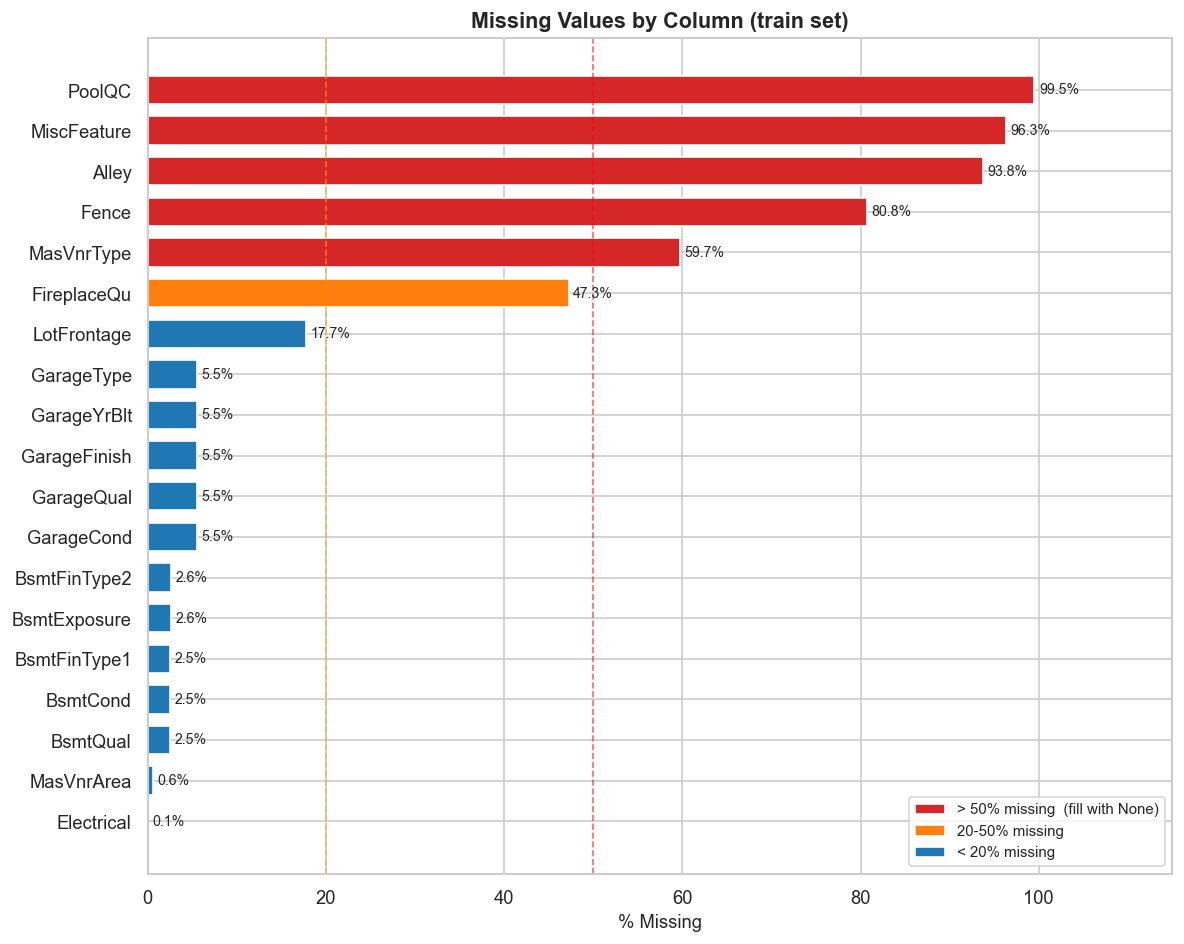

Saved: missing_values_bar.png


In [18]:
from matplotlib.patches import Patch

miss = train_missing.copy()

def bar_color(pct):
    if pct >= 50:   return '#d62728'
    elif pct >= 20: return '#ff7f0e'
    else:           return '#1f77b4'

colors = [bar_color(p) for p in miss['missing_%']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(miss.index, miss['missing_%'], color=colors, edgecolor='white', height=0.7)

for bar, pct in zip(bars, miss['missing_%']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%', va='center', ha='left', fontsize=8.5)

ax.axvline(50, color='red',    linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(20, color='orange', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('% Missing', fontsize=11)
ax.set_title('Missing Values by Column (train set)', fontsize=13, fontweight='bold')
ax.set_xlim(0, 115)
ax.invert_yaxis()

legend_elements = [
    Patch(facecolor='#d62728', label='> 50% missing  (fill with None)'),
    Patch(facecolor='#ff7f0e', label='20-50% missing'),
    Patch(facecolor='#1f77b4', label='< 20% missing')
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('missing_values_bar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: missing_values_bar.png')

---
## Cell 16 — missingno matrix (pattern visualisation)

**How to read it:**
- White gaps = missing values
- Co-occurring gaps in same rows = missing for the same reason
  (e.g. GarageType + GarageFinish + GarageQual all missing = house has no garage)
- The sparkline on the right = data completeness row by row

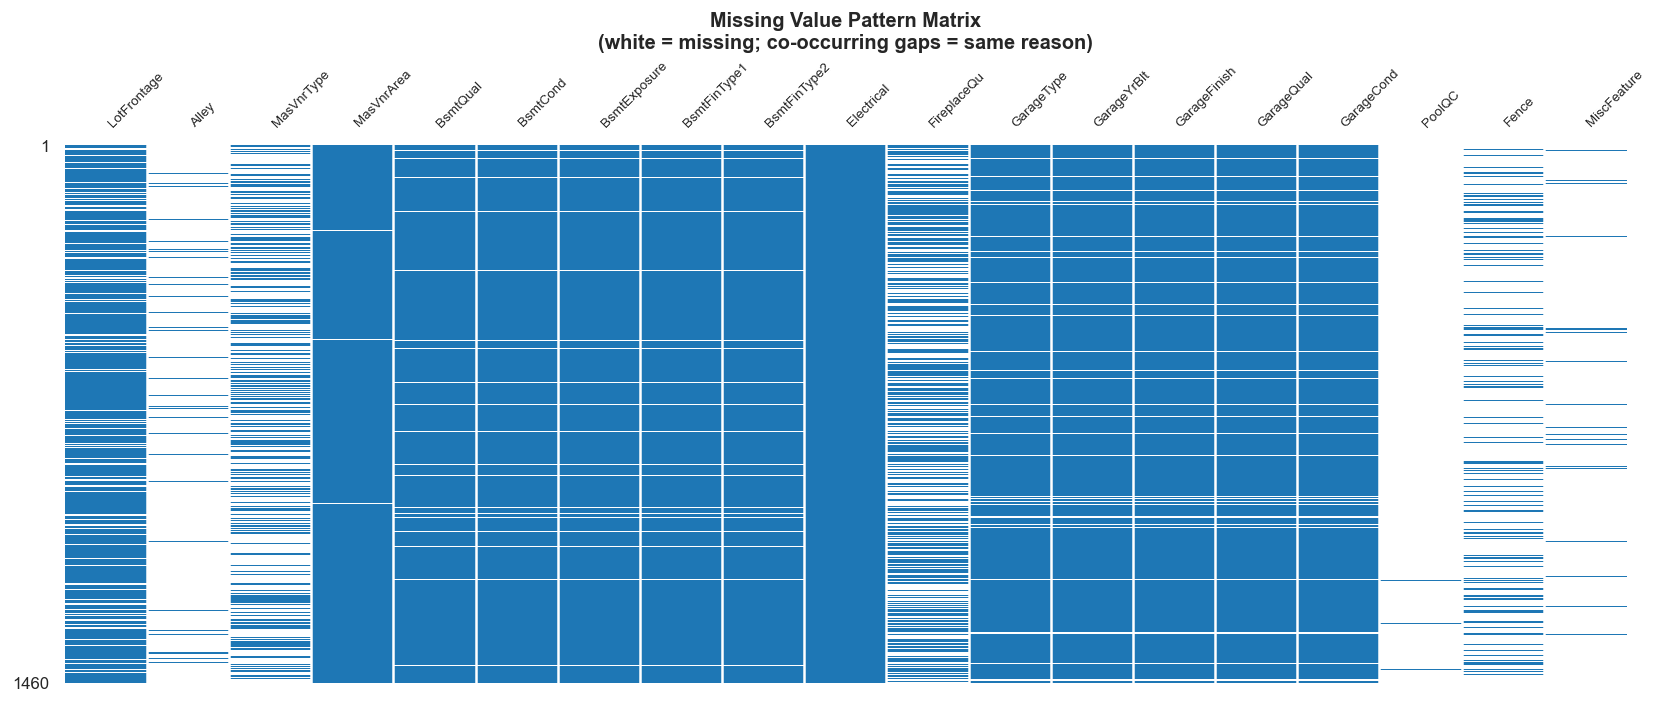

Saved: missing_values_matrix.png

Garage columns that co-occur:   ['GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']
Basement columns that co-occur: ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']

These will all be filled with None / 0 in Phase 3.


In [19]:
cols_with_missing = train.columns[train.isnull().any()].tolist()

fig, ax = plt.subplots(figsize=(14, 6))
msno.matrix(train[cols_with_missing], ax=ax, sparkline=True,
            color=(0.12, 0.47, 0.71), fontsize=8)
ax.set_title('Missing Value Pattern Matrix\n(white = missing; co-occurring gaps = same reason)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('missing_values_matrix.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: missing_values_matrix.png')

garage_cols   = [c for c in cols_with_missing if 'Garage' in c]
basement_cols = [c for c in cols_with_missing if 'Bsmt'   in c]
print(f'\nGarage columns that co-occur:   {garage_cols}')
print(f'Basement columns that co-occur: {basement_cols}')
print('\nThese will all be filled with None / 0 in Phase 3.')

---
## Cell 17 — Correlation with target: ranked table

**What correlation tells you:**
- Pearson correlation ranges from -1 to +1
- +1 = perfect positive relationship (as X increases, SalePrice increases)
- Features with |r| > 0.5 = strong candidates for your model
- Features highly correlated with each other = multicollinearity (hurts linear models)

In [20]:
numeric_train = train.select_dtypes(include=[np.number]).drop(columns=['Id', 'SalePrice'])
corr_matrix   = numeric_train.corr()

target_corr   = corr_matrix['SalePrice_log'].drop('SalePrice_log')
top15_features = target_corr.abs().sort_values(ascending=False).head(15).index.tolist()
top15_features = ['SalePrice_log'] + top15_features

print('Top 15 features correlated with log(SalePrice):')
print(target_corr[top15_features[1:]].sort_values(ascending=False).to_string())
print()
print('These are your most predictive raw features before feature engineering.')

Top 15 features correlated with log(SalePrice):
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Fireplaces      0.489450
MasVnrArea      0.430809
BsmtFinSF1      0.372023
LotFrontage     0.355879

These are your most predictive raw features before feature engineering.


---
## Cell 18 — Zoomed correlation heatmap (top 15 + target)

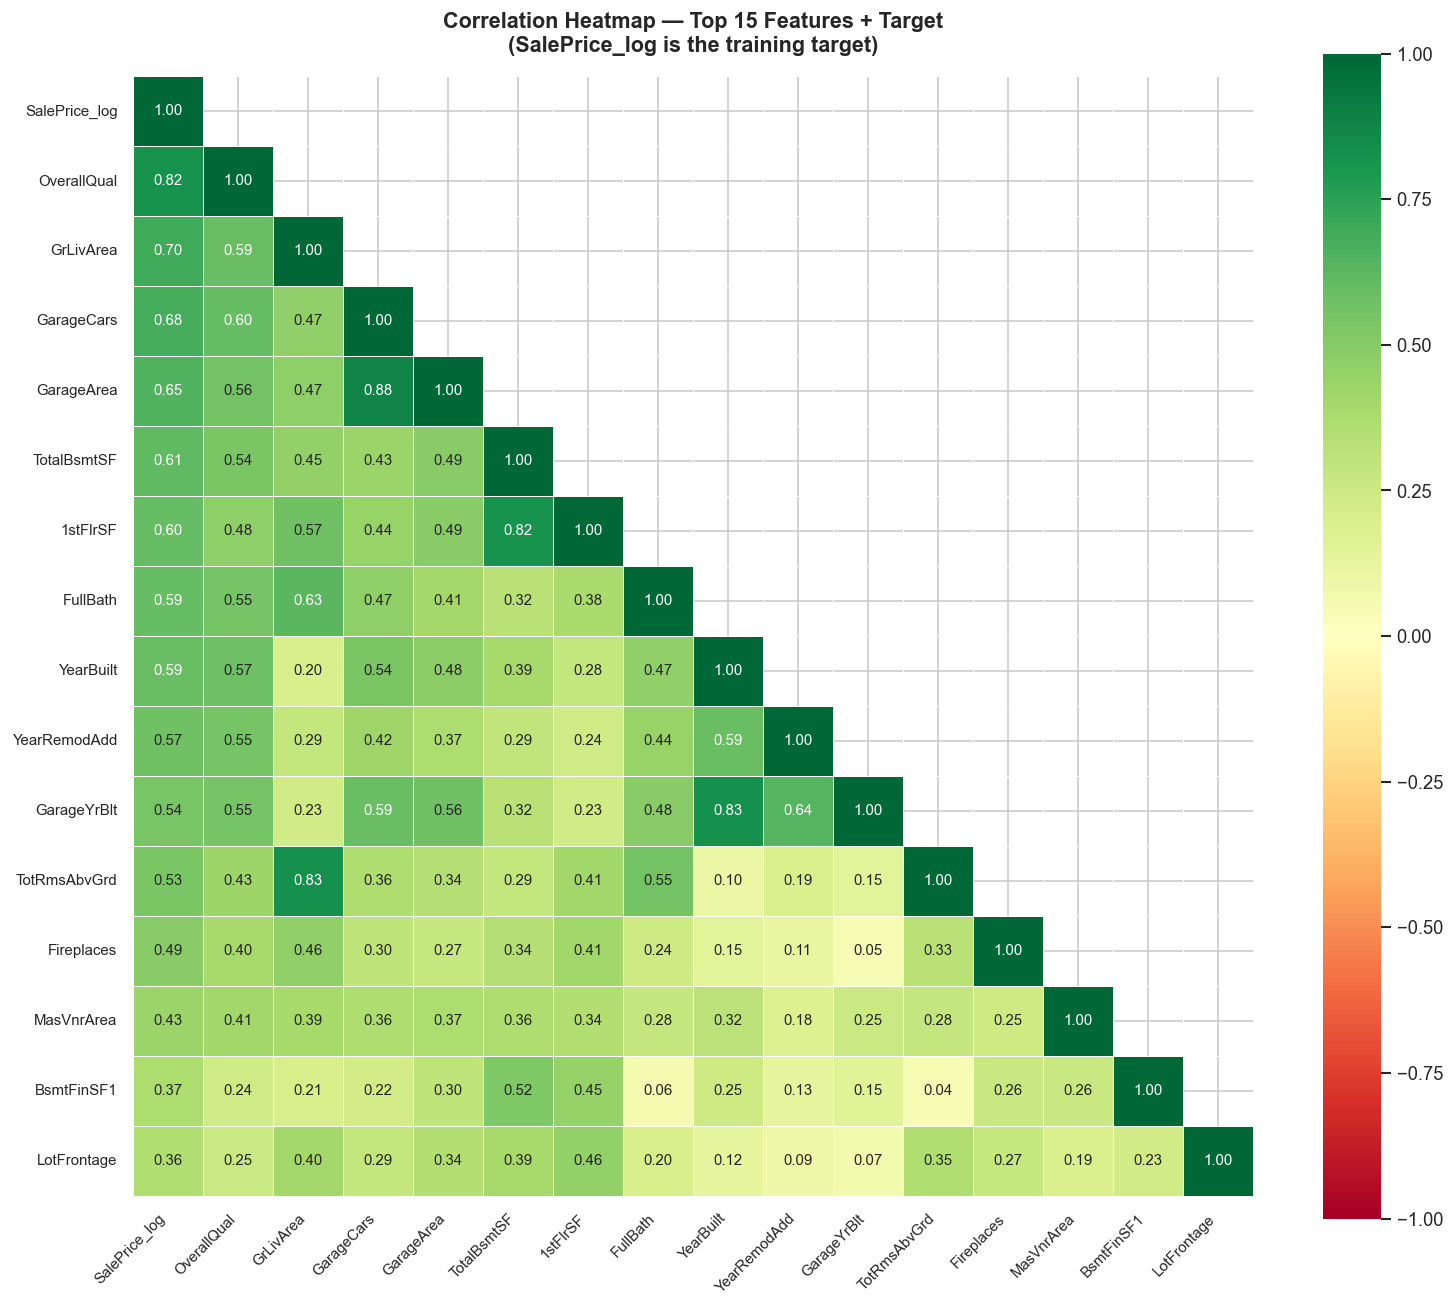

Saved: correlation_heatmap.png


In [21]:
corr_top15 = numeric_train[top15_features].corr()
mask       = np.triu(np.ones_like(corr_top15, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr_top15, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}, ax=ax
)
ax.set_title('Correlation Heatmap — Top 15 Features + Target\n'
             '(SalePrice_log is the training target)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: correlation_heatmap.png')

---
## Cell 19 — SalePrice correlation bar chart

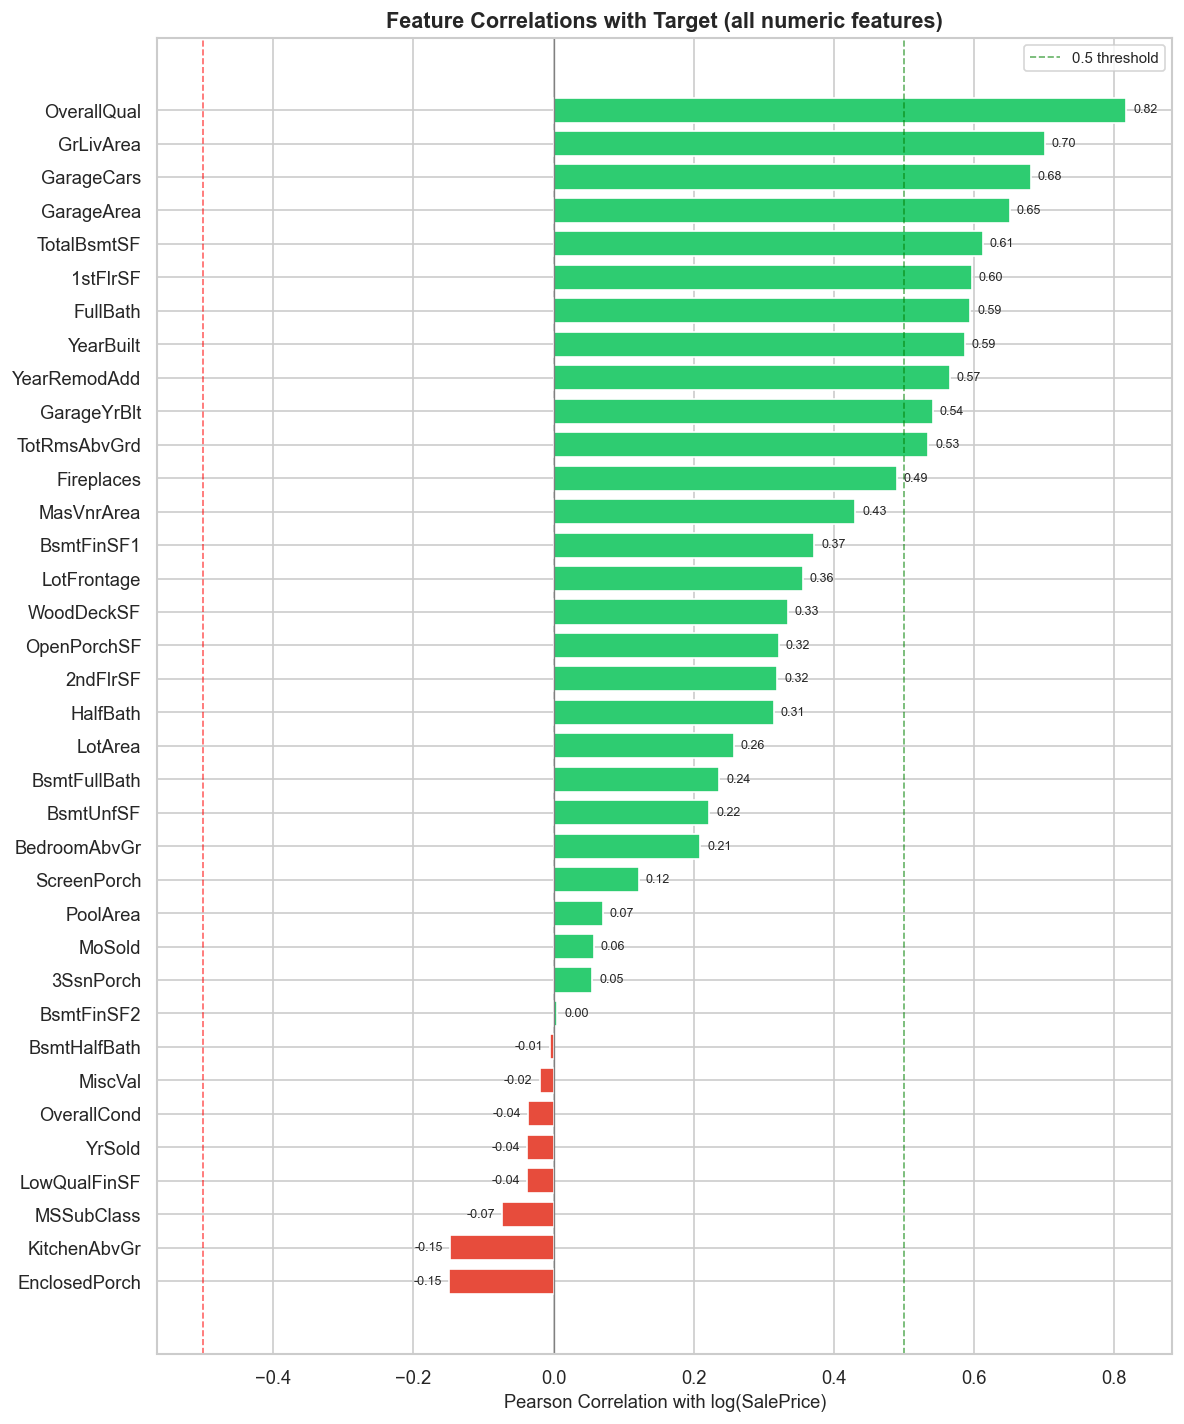

Saved: feature_correlations.png


In [22]:
target_corr_sorted = target_corr.drop('SalePrice_log', errors='ignore').sort_values(ascending=False)
colors_corr        = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr_sorted.values]

fig, ax = plt.subplots(figsize=(10, 12))
ax.barh(target_corr_sorted.index, target_corr_sorted.values,
        color=colors_corr, edgecolor='white', height=0.75)

for i, (val, name) in enumerate(zip(target_corr_sorted.values, target_corr_sorted.index)):
    offset = 0.01 if val >= 0 else -0.01
    ha     = 'left'  if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:.2f}', va='center', ha=ha, fontsize=7.5)

ax.axvline(0,    color='gray',  linewidth=0.8)
ax.axvline( 0.5, color='green', linestyle='--', linewidth=1, alpha=0.6, label='0.5 threshold')
ax.axvline(-0.5, color='red',   linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Pearson Correlation with log(SalePrice)', fontsize=11)
ax.set_title('Feature Correlations with Target (all numeric features)',
             fontsize=13, fontweight='bold')
ax.invert_yaxis()
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('feature_correlations.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: feature_correlations.png')

---
## Cell 20 — Scatter plots: top 6 numeric features vs SalePrice
Correlation numbers tell you strength; scatter plots reveal shape.
The GrLivArea scatter is where you will spot the two famous outliers clearly —
two points with very large area but abnormally low price.

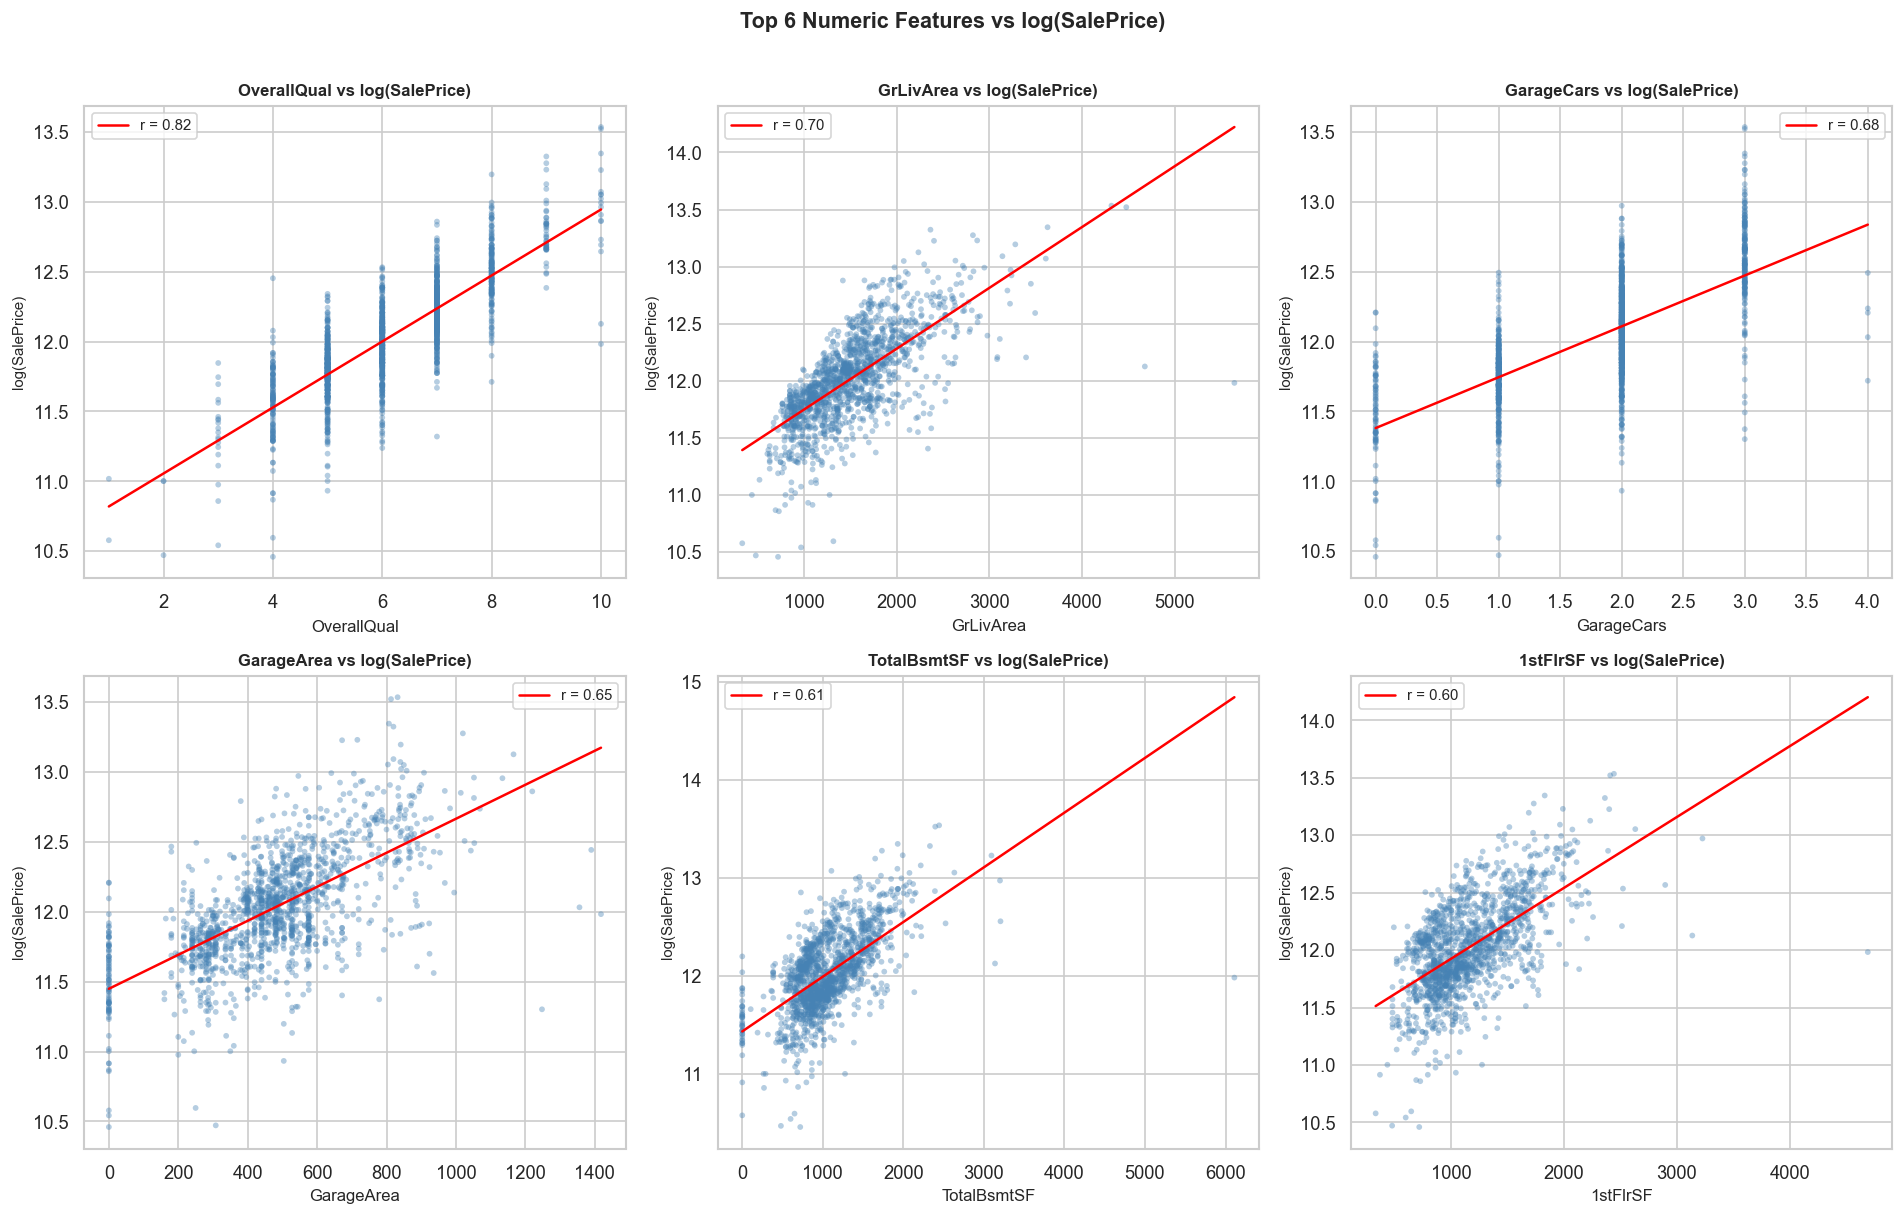

Saved: scatter_top6.png


In [23]:
top6    = target_corr_sorted.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes    = axes.flatten()

for i, feat in enumerate(top6):
    ax = axes[i]
    ax.scatter(train[feat], train['SalePrice_log'],
               alpha=0.4, s=12, color='steelblue', edgecolors='none')
    m, b   = np.polyfit(train[feat].fillna(0), train['SalePrice_log'], 1)
    x_line = np.linspace(train[feat].min(), train[feat].max(), 200)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5,
            label=f'r = {target_corr[feat]:.2f}')
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('log(SalePrice)', fontsize=9)
    ax.set_title(f'{feat} vs log(SalePrice)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Top 6 Numeric Features vs log(SalePrice)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scatter_top6.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: scatter_top6.png')

---
## Cell 21 — Outlier detection: GrLivArea

**The two famous outliers:**
The Kaggle data description explicitly flags two properties with very large GrLivArea
(>4000 sq ft) but abnormally low SalePrice — likely partial sales or foreclosures,
not market-rate transactions.

**Why removing them helps:**
Linear models fit a line through all points. Two extreme outliers tilt the regression
line, degrading predictions for all normal houses. Tree models are more robust,
but removing clearly bad data is always good practice.

**Rule of thumb:** Only remove outliers you can justify with domain knowledge,
not just statistical rules.

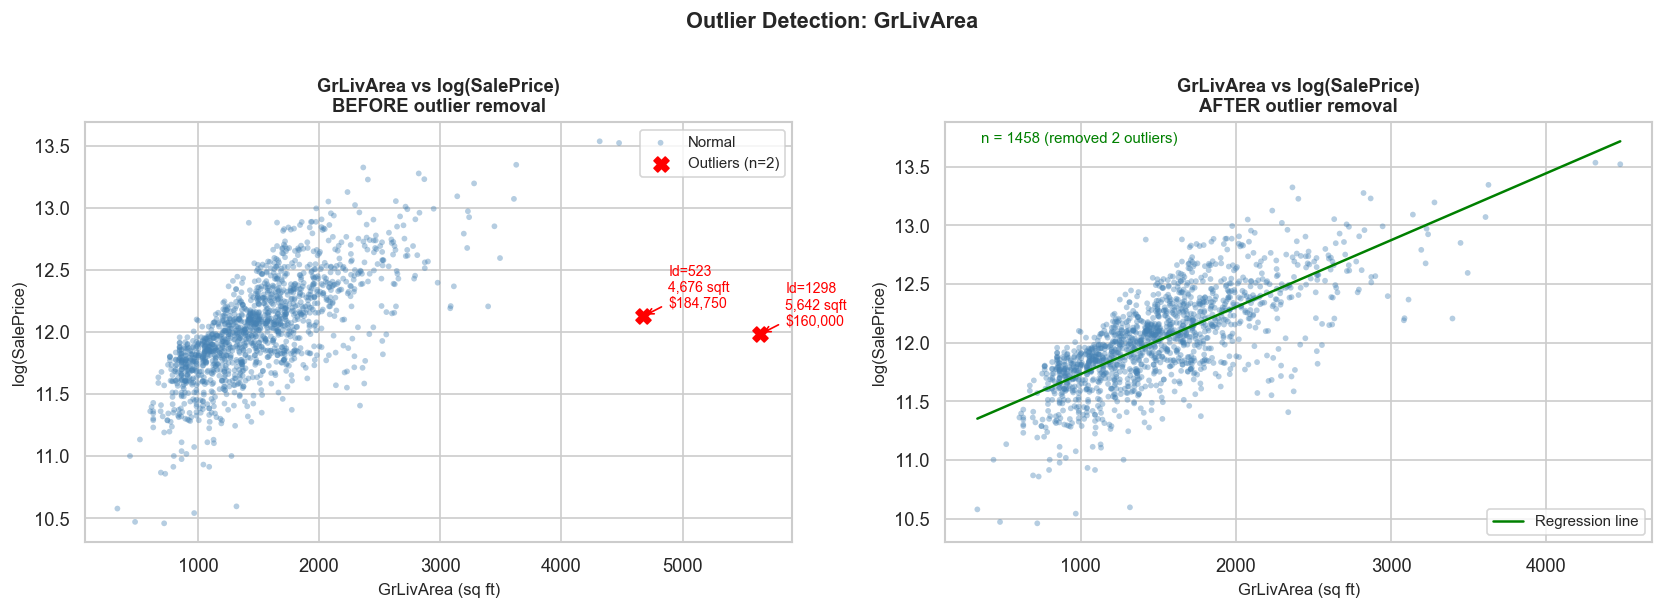

Saved: outlier_detection.png
Outliers removed : 2
Train rows before: 1460
Train rows after : 1458


In [24]:
outlier_mask = (train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)
normal_mask  = ~outlier_mask

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Before removal
ax = axes[0]
ax.scatter(train.loc[normal_mask,  'GrLivArea'], train.loc[normal_mask,  'SalePrice_log'],
           alpha=0.4, s=12, color='steelblue', label='Normal', edgecolors='none')
ax.scatter(train.loc[outlier_mask, 'GrLivArea'], train.loc[outlier_mask, 'SalePrice_log'],
           alpha=1.0, s=80, color='red', marker='X', zorder=5,
           label=f'Outliers (n={outlier_mask.sum()})')
for idx in train[outlier_mask].index:
    ax.annotate(
        f"Id={idx}\n{train.loc[idx,'GrLivArea']:,} sqft\n${train.loc[idx,'SalePrice']:,}",
        xy=(train.loc[idx, 'GrLivArea'], train.loc[idx, 'SalePrice_log']),
        xytext=(15, 5), textcoords='offset points', fontsize=8.5, color='red',
        arrowprops=dict(arrowstyle='->', color='red', lw=1)
    )
ax.set_xlabel('GrLivArea (sq ft)', fontsize=10)
ax.set_ylabel('log(SalePrice)',     fontsize=10)
ax.set_title('GrLivArea vs log(SalePrice)\nBEFORE outlier removal', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

# Right: After removal
ax          = axes[1]
train_clean = train[~outlier_mask].copy()
ax.scatter(train_clean['GrLivArea'], train_clean['SalePrice_log'],
           alpha=0.4, s=12, color='steelblue', edgecolors='none')
m, b   = np.polyfit(train_clean['GrLivArea'], train_clean['SalePrice_log'], 1)
x_line = np.linspace(train_clean['GrLivArea'].min(), train_clean['GrLivArea'].max(), 200)
ax.plot(x_line, m * x_line + b, color='green', linewidth=1.5, label='Regression line')
ax.set_xlabel('GrLivArea (sq ft)', fontsize=10)
ax.set_ylabel('log(SalePrice)',     fontsize=10)
ax.set_title('GrLivArea vs log(SalePrice)\nAFTER outlier removal', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.annotate(f'n = {len(train_clean)} (removed {outlier_mask.sum()} outliers)',
            xy=(0.05, 0.95), xycoords='axes fraction', fontsize=9, color='green')

plt.suptitle('Outlier Detection: GrLivArea', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outlier_detection.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: outlier_detection.png')
print(f'Outliers removed : {outlier_mask.sum()}')
print(f'Train rows before: {len(train)}')
print(f'Train rows after : {len(train_clean)}')

---
## Cell 22 — Apply outlier removal + lock in the log target

This is the one destructive step in EDA. From here forward, all phases use the
cleaned `train`. We also define `y` (log-transformed SalePrice) and combine
train + test into `all_data` for unified preprocessing in Phase 3.

**Why combine train and test for preprocessing?**
So that pd.get_dummies() produces identical columns in both. If a Neighborhood
only appears in the test set, encoding separately means that column won't exist
in train — your model will crash at prediction time.

In [25]:
# Step 1: Remove outliers
train = train[~outlier_mask].reset_index(drop=True)

# Step 2: Define y — used in ALL future phases as training labels
y = train['SalePrice_log'].copy()

# Step 3: Combine train + test for unified preprocessing
n_train  = len(train)
n_test   = len(test)
all_data = pd.concat(
    [train.drop(columns=['SalePrice', 'SalePrice_log']), test],
    axis=0
).reset_index(drop=True)

print(f'y shape        : {y.shape}')
print(f'all_data shape : {all_data.shape}  (train + test combined)')
print(f'n_train        : {n_train}')
print(f'n_test         : {n_test}')
print()
print('Variables ready for Phase 3:')
print('  train     — cleaned training DataFrame')
print('  test      — test DataFrame')
print('  all_data  — train+test combined (preprocessing target)')
print('  y         — log(SalePrice) labels')
print('  n_train   — used to split all_data back after encoding')

y shape        : (1458,)
all_data shape : (2917, 80)  (train + test combined)
n_train        : 1458
n_test         : 1459

Variables ready for Phase 3:
  train     — cleaned training DataFrame
  test      — test DataFrame
  all_data  — train+test combined (preprocessing target)
  y         — log(SalePrice) labels
  n_train   — used to split all_data back after encoding


---
## Cell 23 — OverallQual and Neighborhood analysis

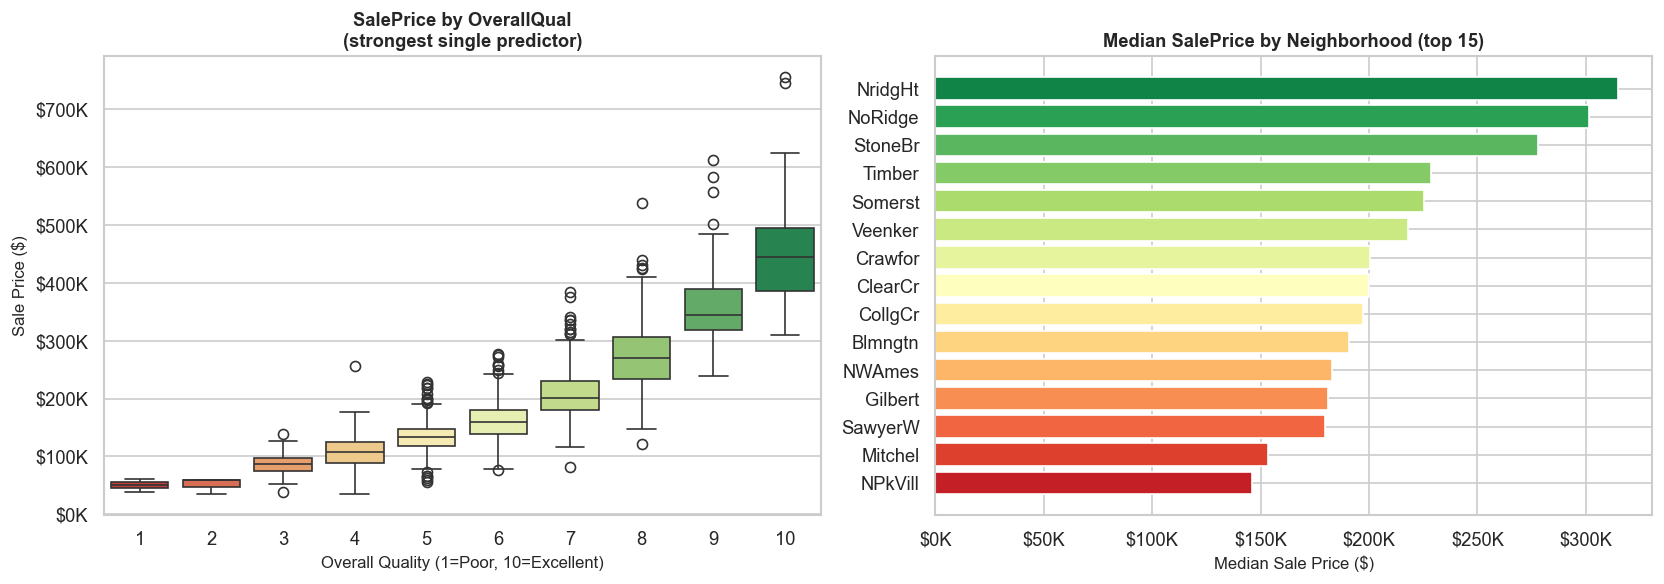

Saved: categorical_analysis.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Box plot of SalePrice by OverallQual
ax          = axes[0]
qual_order  = sorted(train['OverallQual'].unique())
sns.boxplot(data=train, x='OverallQual', y='SalePrice',
            order=qual_order, palette='RdYlGn', ax=ax)
ax.set_title('SalePrice by OverallQual\n(strongest single predictor)', fontsize=11, fontweight='bold')
ax.set_xlabel('Overall Quality (1=Poor, 10=Excellent)', fontsize=10)
ax.set_ylabel('Sale Price ($)', fontsize=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

# Right: Median SalePrice by Neighborhood (top 15)
ax                   = axes[1]
neighborhood_medians = (train.groupby('Neighborhood')['SalePrice']
                             .median()
                             .sort_values(ascending=False)
                             .head(15))
colors_n = sns.color_palette('RdYlGn', len(neighborhood_medians))
ax.barh(neighborhood_medians.index[::-1], neighborhood_medians.values[::-1],
        color=colors_n, edgecolor='white')
ax.set_title('Median SalePrice by Neighborhood (top 15)', fontsize=11, fontweight='bold')
ax.set_xlabel('Median Sale Price ($)', fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig('categorical_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: categorical_analysis.png')

---
## Cell 24 — Phase 2 EDA summary checkpoint

In [27]:
print('=' * 60)
print('  PHASE 2 EDA CHECKPOINT')
print('=' * 60)
print(f'  Training rows (after outlier removal)  : {len(train)}')
print(f'  Outliers removed                        : 2')
print()
print('  Target variable:')
print(f'    SalePrice skewness (raw)              : {train["SalePrice"].skew():.3f}')
print(f'    SalePrice skewness (log-transformed)  : {y.skew():.3f}')
print()
print('  Missing values:')
print(f'    Columns with NaN                      : {(train.isnull().sum() > 0).sum()}')
print(f'    High-missing cols (>50%)              : PoolQC, MiscFeature, Alley, Fence, FireplaceQu')
print()
print('  Top 5 correlated features with log(SalePrice):')
top5 = target_corr.abs().sort_values(ascending=False).head(5)
for feat, corr_val in top5.items():
    print(f'    {feat:<20}  r = {corr_val:.3f}')
print()
print('  Saved plots:')
for fname in ['target_analysis.png', 'missing_values_bar.png', 'missing_values_matrix.png',
              'correlation_heatmap.png', 'feature_correlations.png',
              'scatter_top6.png', 'outlier_detection.png', 'categorical_analysis.png']:
    print(f'    {fname}')
print()
print('  Ready for: Phase 3 — Imputation and Encoding')
print('=' * 60)

  PHASE 2 EDA CHECKPOINT
  Training rows (after outlier removal)  : 1458
  Outliers removed                        : 2

  Target variable:
    SalePrice skewness (raw)              : 1.881
    SalePrice skewness (log-transformed)  : 0.122

  Missing values:
    Columns with NaN                      : 19
    High-missing cols (>50%)              : PoolQC, MiscFeature, Alley, Fence, FireplaceQu

  Top 5 correlated features with log(SalePrice):
    OverallQual           r = 0.817
    GrLivArea             r = 0.701
    GarageCars            r = 0.681
    GarageArea            r = 0.651
    TotalBsmtSF           r = 0.612

  Saved plots:
    target_analysis.png
    missing_values_bar.png
    missing_values_matrix.png
    correlation_heatmap.png
    feature_correlations.png
    scatter_top6.png
    outlier_detection.png
    categorical_analysis.png

  Ready for: Phase 3 — Imputation and Encoding
